In [125]:
# Authenticate
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")


In [126]:
!kaggle competitions download -c digit-recognizer --path /content
!unzip -o /content/digit-recognizer.zip -d /content/digit-recognizer

digit-recognizer.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/digit-recognizer.zip
  inflating: /content/digit-recognizer/sample_submission.csv  
  inflating: /content/digit-recognizer/test.csv  
  inflating: /content/digit-recognizer/train.csv  


In [127]:
import pandas as pd
import numpy as np

In [128]:
df=pd.read_csv('/content/digit-recognizer/train.csv')

In [129]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [130]:
df.shape

(42000, 785)

In [131]:
import matplotlib.pyplot as plt

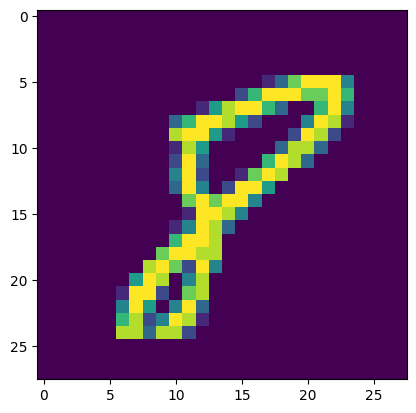

In [132]:
plt.imshow(df.iloc[18306,1:].values.reshape(28,28))

In [133]:
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [134]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [135]:
x_train.shape

(33600, 784)

In [136]:
from sklearn.neighbors import KNeighborsClassifier

In [137]:
kn=KNeighborsClassifier()

In [138]:
kn.fit(x_train,y_train)

KNeighborsClassifier()

In [139]:
import time
start=time.time()
y_pred=kn.predict(x_test)
print(time.time()-start)

21.442865133285522


In [140]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9680952380952381

In [141]:
# now we are going to do the pca and then check the outputs

In [142]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [143]:
from sklearn.decomposition import PCA
pca=PCA(n_components=50)
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)
x_train_trf.shape

(33600, 50)

In [144]:
kn=KNeighborsClassifier()
kn.fit(x_train_trf,y_train)

KNeighborsClassifier()

In [145]:
y_pred=kn.predict(x_test_trf)
accuracy_score(y_test,y_pred)

0.9530952380952381

In [146]:
for i in range (1,785,49):
  pca=PCA(n_components=i)
  x_train_trf=pca.fit_transform(x_train)
  x_test_trf=pca.transform(x_test)
  kn=KNeighborsClassifier()
  kn.fit(x_train_trf,y_train)
  y_pred=kn.predict(x_test_trf)
  print(i,accuracy_score(y_test,y_pred))

1 0.2636904761904762
50 0.9530952380952381
99 0.9548809523809524
148 0.9517857142857142
197 0.9508333333333333
246 0.9479761904761905
295 0.9460714285714286
344 0.9422619047619047
393 0.9419047619047619
442 0.940952380952381
491 0.9403571428571429
540 0.9391666666666667
589 0.9391666666666667
638 0.9392857142857143
687 0.9385714285714286
736 0.9386904761904762


In [147]:
pca=PCA(n_components=2)# for 2d coordinate visualization
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [148]:
import plotly.express as px
y_train_trf=y_train.astype(str)
fig=px.scatter(x=x_train_trf[:,0],y=x_train_trf[:,1],color=y_train_trf,color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

In [149]:
#for 3d visualization
pca=PCA(n_components=3)
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [150]:
y_train_trf=y_train.astype(str)
fig=px.scatter_3d(x=x_train_trf[:,0], y=x_train_trf[:,1], z=x_train_trf[:,2], color=y_train_trf)
fig.update_layout(margin=dict(l=20, r=20, b=20, t=20))
fig.show()

In [151]:
pca.explained_variance_#this is the eigen value

array([40.64115119, 29.26140855, 26.64277388])

In [152]:
pca.components_# eigen vec

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])

In [153]:
pca.explained_variance_ratio_# this is the percentage value div by 100

array([0.05830695, 0.04198069, 0.03822379])

In [154]:
pca=PCA(n_components=None)
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)
x_train_trf.shape

(33600, 784)

In [155]:
pca.explained_variance_ratio_

array([5.83069464e-02, 4.19806853e-02, 3.82237890e-02, 2.99115159e-02,
       2.58748632e-02, 2.27008412e-02, 1.99181162e-02, 1.79797980e-02,
       1.59385496e-02, 1.44560523e-02, 1.38562105e-02, 1.24492919e-02,
       1.15119932e-02, 1.13424713e-02, 1.07110491e-02, 1.02951072e-02,
       9.66728711e-03, 9.47629549e-03, 9.28196326e-03, 9.03792228e-03,
       8.53649059e-03, 8.26288062e-03, 7.94170437e-03, 7.63846377e-03,
       7.41556539e-03, 7.11610601e-03, 7.04734462e-03, 6.81501263e-03,
       6.44113258e-03, 6.29955011e-03, 6.23008130e-03, 6.14309357e-03,
       5.93474807e-03, 5.81338525e-03, 5.78103546e-03, 5.62246157e-03,
       5.51424377e-03, 5.31447897e-03, 5.16496129e-03, 5.04507920e-03,
       4.94783916e-03, 4.89615197e-03, 4.72839588e-03, 4.70319591e-03,
       4.58153617e-03, 4.54549102e-03, 4.52189700e-03, 4.47588589e-03,
       4.36530486e-03, 4.28496360e-03, 4.14376740e-03, 4.10474105e-03,
       4.06067246e-03, 4.00513090e-03, 3.95755427e-03, 3.82446042e-03,
      

In [156]:
pca.components_

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.]])

In [157]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05830695, 0.10028763, 0.13851142, 0.16842294, 0.1942978 ,
       0.21699864, 0.23691676, 0.25489656, 0.2708351 , 0.28529116,
       0.29914737, 0.31159666, 0.32310865, 0.33445112, 0.34516217,
       0.35545728, 0.36512457, 0.37460086, 0.38388283, 0.39292075,
       0.40145724, 0.40972012, 0.41766182, 0.42530029, 0.43271585,
       0.43983196, 0.4468793 , 0.45369432, 0.46013545, 0.466435  ,
       0.47266508, 0.47880817, 0.48474292, 0.49055631, 0.49633734,
       0.5019598 , 0.50747405, 0.51278853, 0.51795349, 0.52299857,
       0.52794641, 0.53284256, 0.53757095, 0.54227415, 0.54685569,
       0.55140118, 0.55592307, 0.56039896, 0.56476427, 0.56904923,
       0.573193  , 0.57729774, 0.58135841, 0.58536354, 0.5893211 ,
       0.59314556, 0.5969215 , 0.6006662 , 0.60430766, 0.60791184,
       0.61141996, 0.61491038, 0.61834564, 0.62177429, 0.6251811 ,
       0.62851747, 0.63182195, 0.63504067, 0.63824855, 0.64141191,
       0.64453498, 0.6476157 , 0.65067708, 0.65371506, 0.65673

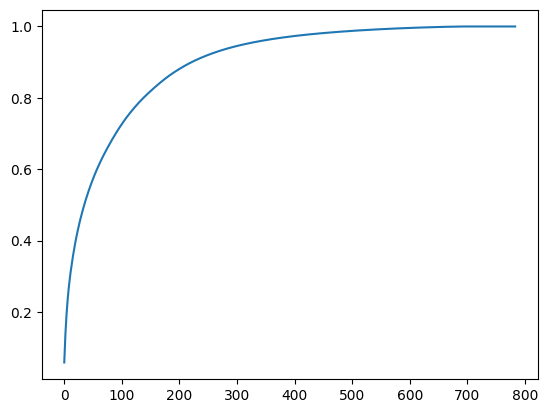

In [158]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [159]:
#so the 90 percent is getting explained around 200-250 and 95 percent around 400